# Level 2: Churn Prediction (Classification)

This section implements:
- Logistic Regression
- Decision Tree
- Evaluation using confusion matrix and accuracy

In [23]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
train_df = pd.read_csv('churn-bigml-80.csv')
test_df = pd.read_csv('churn-bigml-20.csv')

print(train_df.shape)
print(test_df.shape)

(2666, 20)
(667, 20)


In [6]:
print(train_df.columns)
train_df.head()

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


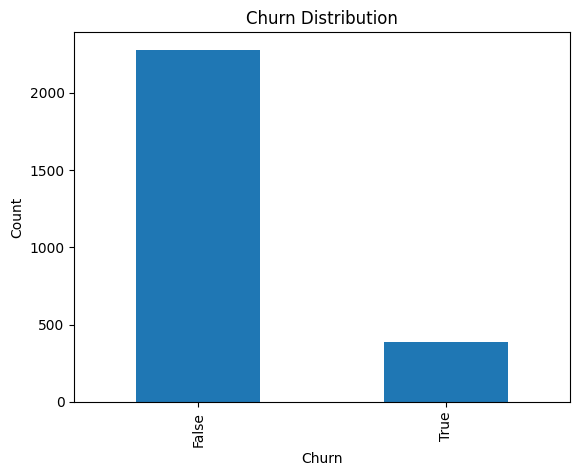

In [17]:
import matplotlib.pyplot as plt

train_df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show() #showing imbalance

In [7]:
full_df = pd.concat([train_df, test_df], ignore_index=True)

In [8]:
for col in full_df.columns:
    if full_df[col].dtype == 'object':
        full_df[col].fillna(full_df[col].mode()[0], inplace=True)
    else:
        full_df[col].fillna(full_df[col].mean(), inplace=True)

/tmp/ipykernel_631/3386171732.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_df[col].fillna(full_df[col].mode()[0], inplace=True)
/tmp/ipykernel_631/3386171732.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [9]:
le = LabelEncoder()

for col in full_df.select_dtypes(include='object').columns:
    full_df[col] = le.fit_transform(full_df[col])

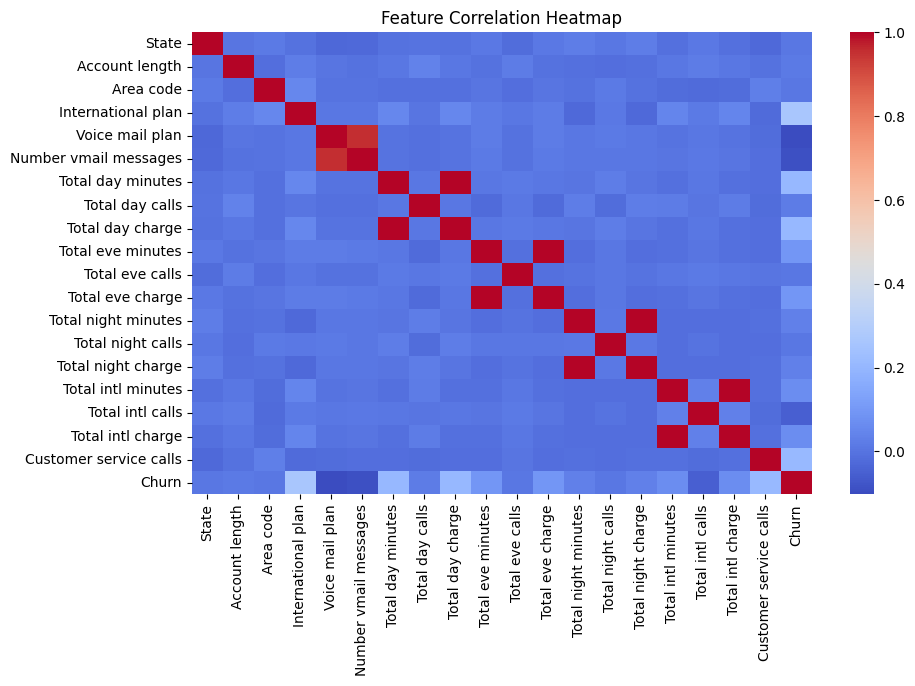

In [18]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(full_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
train_df = full_df.iloc[:len(train_df)]
test_df = full_df.iloc[len(train_df):]

In [12]:
target = 'Churn'

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [13]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

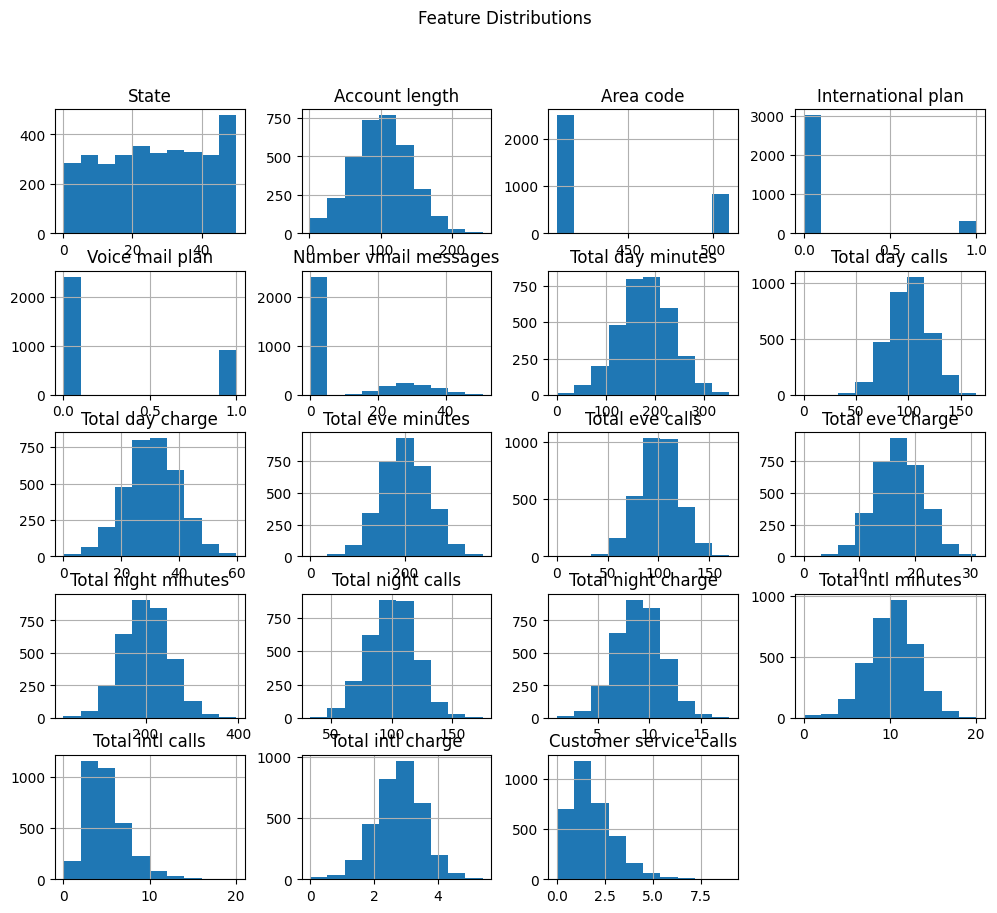

In [19]:
full_df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

#Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred_log = log.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8530734632683659
              precision    recall  f1-score   support

       False       0.88      0.97      0.92       572
        True       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667



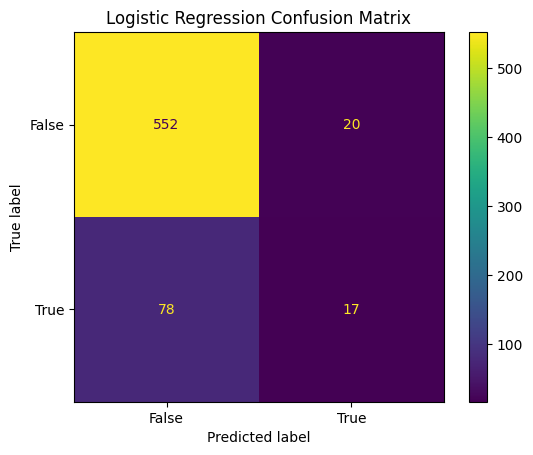

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9535232383808095


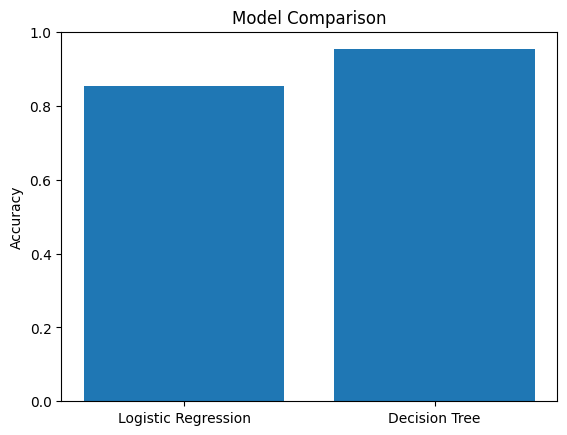

In [21]:
acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)

models = ['Logistic Regression', 'Decision Tree']
scores = [acc_log, acc_dt]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

#Confusion Matrix

In [16]:
print("Confusion Matrix (Logistic):")
print(confusion_matrix(y_test, y_pred_log))

Confusion Matrix (Logistic):
[[552  20]
 [ 78  17]]


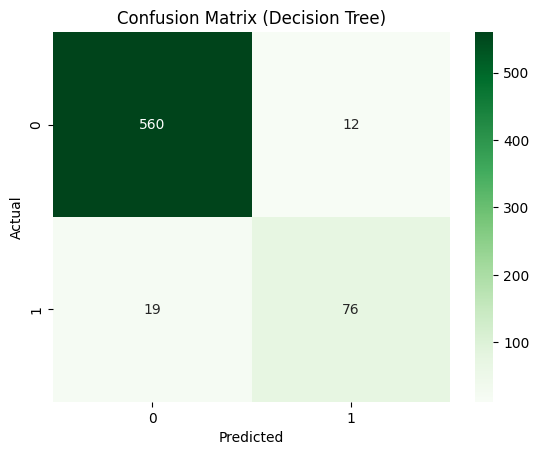

In [22]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Decision Tree)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Level 3: Advanced Machine Learning Models

This section implements:
- Random Forest
- Support Vector Machine (SVM)
- Model comparison and feature importance

#Train Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9445277361319341
              precision    recall  f1-score   support

       False       0.95      0.99      0.97       572
        True       0.93      0.66      0.77        95

    accuracy                           0.94       667
   macro avg       0.94      0.83      0.87       667
weighted avg       0.94      0.94      0.94       667



#Confusion Matrix (Random Forest)

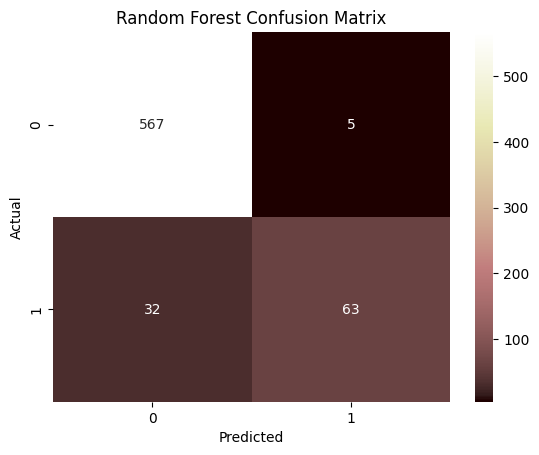

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='pink')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

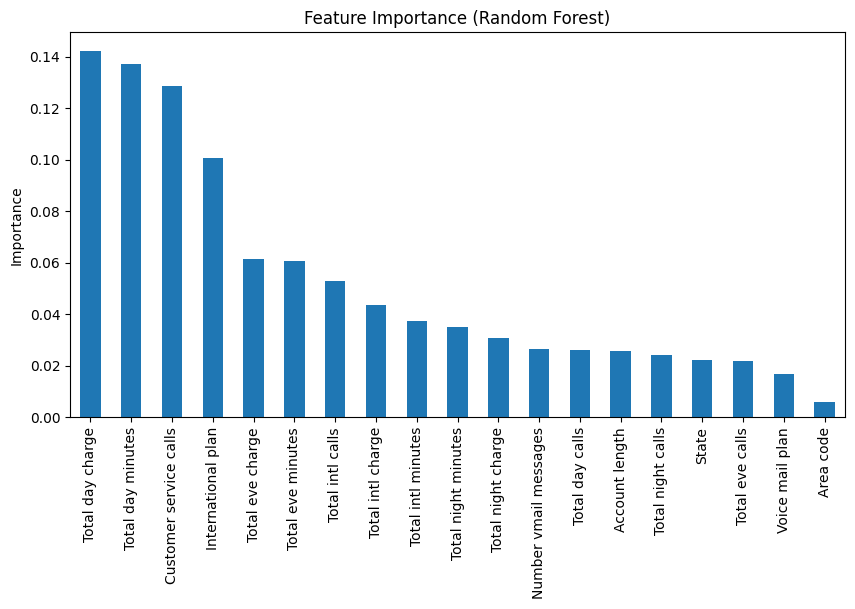

In [27]:
import pandas as pd

importances = rf.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

In [28]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)

print("SVM (Linear) Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM (Linear) Accuracy: 0.8575712143928036
              precision    recall  f1-score   support

       False       0.86      1.00      0.92       572
        True       0.00      0.00      0.00        95

    accuracy                           0.86       667
   macro avg       0.43      0.50      0.46       667
weighted avg       0.74      0.86      0.79       667



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("SVM (RBF) Accuracy:", accuracy_score(y_test, y_pred_rbf))

SVM (RBF) Accuracy: 0.9190404797601199


#Confusion Matrix (SVM)

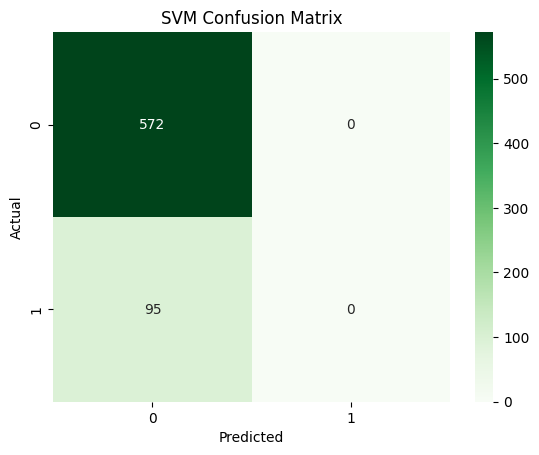

In [35]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

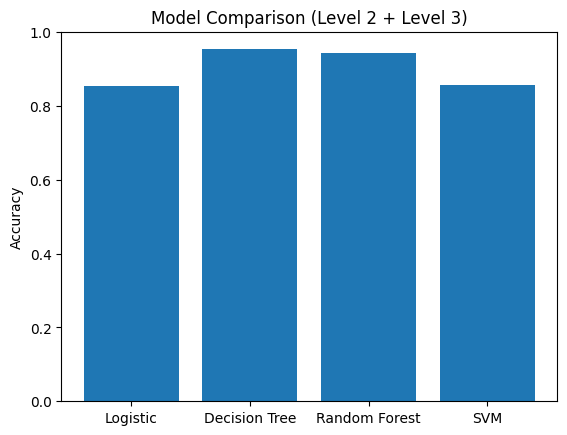

In [36]:
# Level 2 models
acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Level 3 models
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_svm = accuracy_score(y_test, y_pred_svm)

models = ['Logistic', 'Decision Tree', 'Random Forest', 'SVM']
scores = [acc_log, acc_dt, acc_rf, acc_svm]

plt.bar(models, scores)
plt.title("Model Comparison (Level 2 + Level 3)")
plt.ylabel("Accuracy")
plt.show()

# Conclusion

- Logistic Regression provides a simple baseline model
- Decision Tree improves interpretability
- Random Forest gives the best performance due to ensemble learning
- SVM performs well for complex decision boundaries

Overall, Random Forest achieved the highest accuracy and is the most reliable model for this dataset.